# Regressionsanalyse – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/regression)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 19.01.2026

Die **Regressionsanalyse** modelliert Beziehungen zwischen einer **abhängigen Variable**
(Kriterium, AV) und einer oder mehreren **unabhängigen Variablen** (Prädiktoren, UV).

**Zwei Ziele:**
1. **Einfluss messen** – Hat UV einen Einfluss auf AV?
2. **Vorhersage** – Wie lässt sich AV durch UV vorhersagen?

**Welche Regression?**

| Methode | Anzahl UV | Skalenniveau AV | Typisches Beispiel |
|---|---|---|---|
| **Einfache lineare Regression** | 1 | Metrisch | Arbeitszeit → Stundenlohn |
| **Multiple lineare Regression** | Mehrere | Metrisch | Alter + Arbeitszeit → Stundenlohn |
| **Logistische Regression** | Mehrere | Nominal/Ordinal | Alter + Arbeitszeit → Burnout (ja/nein) |

**UV-Skalenniveau:** Beliebig (metrisch, ordinal, nominal)
→ Bei nominal/ordinal mit >2 Kategorien: **Dummy-Variablen** nötig!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pearsonr
import statsmodels.api as sm
import statsmodels.formula.api as smf

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Die drei Regressionsarten im Überblick

**numiqo-Beispiel:** Einfluss von Arbeitszeit (und Alter) auf Stundenlohn / Burnout-Gefährdung

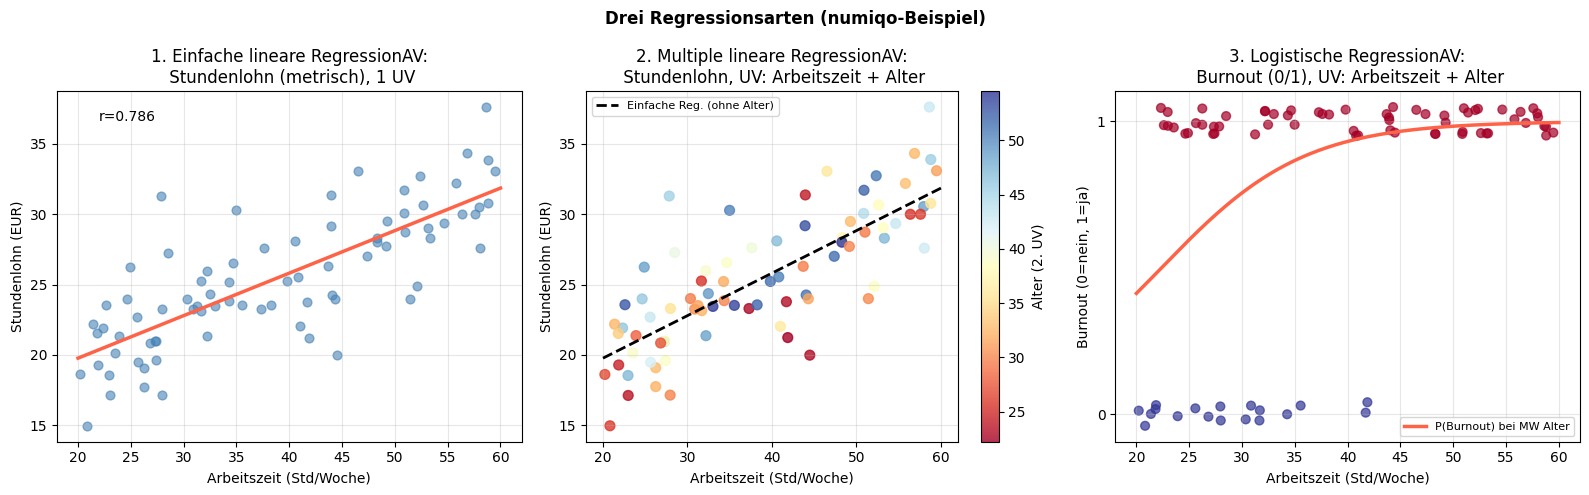

In [5]:
np.random.seed(42)
n = 80

# Daten generieren
arbeitszeit = np.random.uniform(20, 60, n)
alter       = np.random.uniform(22, 55, n)
stundenlohn = 8 + 0.3 * arbeitszeit + 0.15 * alter + np.random.normal(0, 3, n)
burnout_log = -3 + 0.06 * arbeitszeit + 0.04 * alter + np.random.normal(0, 0.5, n)
burnout     = (burnout_log > 0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Drei Regressionsarten (numiqo-Beispiel)", fontsize=12, fontweight="bold")

# 1. Einfache lineare Regression
r1, _ = pearsonr(arbeitszeit, stundenlohn)
m1, b1 = np.polyfit(arbeitszeit, stundenlohn, 1)
axes[0].scatter(arbeitszeit, stundenlohn, color="steelblue", alpha=0.6, s=40)
x1 = np.linspace(20, 60, 100)
axes[0].plot(x1, m1*x1+b1, color="tomato", linewidth=2.5)
axes[0].set_title("1. Einfache lineare RegressionAV:\n Stundenlohn (metrisch), 1 UV")
axes[0].set_xlabel("Arbeitszeit (Std/Woche)")
axes[0].set_ylabel("Stundenlohn (EUR)")
axes[0].grid(alpha=0.3)
axes[0].text(22, stundenlohn.max()-1, "r=" + str(round(r1, 3)), fontsize=10)

# 2. Multiple lineare Regression (Visualisierung: Alter als Farbe)
sc2 = axes[1].scatter(arbeitszeit, stundenlohn, c=alter, cmap="RdYlBu",
                      s=50, alpha=0.8)
plt.colorbar(sc2, ax=axes[1], label="Alter (2. UV)")
axes[1].plot(x1, m1*x1+b1, color="black", linewidth=2, linestyle="--",
             label="Einfache Reg. (ohne Alter)")
axes[1].set_title("2. Multiple lineare RegressionAV:\n Stundenlohn, UV: Arbeitszeit + Alter")
axes[1].set_xlabel("Arbeitszeit (Std/Woche)")
axes[1].set_ylabel("Stundenlohn (EUR)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# 3. Logistische Regression
from scipy.special import expit
log_model = sm.Logit(burnout, sm.add_constant(np.column_stack([arbeitszeit, alter])))
log_result = log_model.fit(disp=0)
axes[2].scatter(arbeitszeit, burnout + np.random.uniform(-0.05, 0.05, n),
                c=burnout, cmap="RdYlBu_r", s=40, alpha=0.7)
x_log = np.linspace(20, 60, 200)
alter_mean = alter.mean()
logits = log_result.params[0] + log_result.params[1]*x_log + log_result.params[2]*alter_mean
axes[2].plot(x_log, expit(logits), color="tomato", linewidth=2.5,
             label="P(Burnout) bei MW Alter")
axes[2].set_title("3. Logistische RegressionAV:\n Burnout (0/1), UV: Arbeitszeit + Alter")
axes[2].set_xlabel("Arbeitszeit (Std/Woche)")
axes[2].set_ylabel("Burnout (0=nein, 1=ja)")
axes[2].set_yticks([0, 1])
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Abhängige vs. Unabhängige Variable

| Begriff | Synonym | Rolle | Skalenniveau |
|---|---|---|---|
| **Abhängige Variable (AV)** | Kriterium, Y | Wird vorhergesagt | Metrisch (lin.) / Nominal (log.) |
| **Unabhängige Variable (UV)** | Prädiktor, X | Sagt vorher | Beliebig |

**Dummy-Variablen:** Nominale UV mit k Kategorien → k−1 Dummy-Variablen
(eine Kategorie = Referenz, kodiert als 0)

In [3]:
# Dummy-Variablen Demonstration
print("Dummy-Variablen: Bildungsniveau (USA)")
print()
print("Original:  High School | College | Graduate")
print("Referenz:  High School (wird weggelassen)")
print()
print("Dummy-Kodierung:")
print("Person  Bildung       is_college  is_graduate")

bildung_bsp = [("High School", 0, 0),
               ("College",     1, 0),
               ("Graduate",    0, 1),
               ("College",     1, 0),
               ("High School", 0, 0)]

for i, (b, c, g) in enumerate(bildung_bsp, 1):
    print(str(i) + "       " + b + "  " + str(c) + "           " + str(g))
print()
print("Interpretation der Regressionskoeffizienten:")
print("  b_is_college:   Mehrgehalt eines College- vs. High-School-Abschluss")
print("  b_is_graduate:  Mehrgehalt eines Graduate- vs. High-School-Abschluss")

# Simulation
np.random.seed(42)
n_d = 90
bildung_idx = np.random.choice([0, 1, 2], n_d)  # 0=HS, 1=College, 2=Graduate
is_college  = (bildung_idx == 1).astype(float)
is_graduate = (bildung_idx == 2).astype(float)
gehalt = 30 + 8*is_college + 18*is_graduate + np.random.normal(0, 5, n_d)

df_d = pd.DataFrame({"gehalt": gehalt, "is_college": is_college, "is_graduate": is_graduate})
model_d = smf.ols("gehalt ~ is_college + is_graduate", data=df_d).fit()

print()
print("Regressionsergebnis mit Dummies")
print("Intercept (= Referenz High School): " + str(round(model_d.params.iloc[0], 2)))
print("b(is_college):                     " + str(round(model_d.params.iloc[1], 2)))
print("b(is_graduate):                    " + str(round(model_d.params.iloc[2], 2)))
print()
print("College verdient im Schnitt " + str(round(model_d.params.iloc[1], 1)) +
      " EUR mehr als High School")
print("Graduate verdient im Schnitt " + str(round(model_d.params.iloc[2], 1)) +
      " EUR mehr als High School")

Dummy-Variablen: Bildungsniveau (USA)

Original:  High School | College | Graduate
Referenz:  High School (wird weggelassen)

Dummy-Kodierung:
Person  Bildung       is_college  is_graduate
1       High School  0           0
2       College  1           0
3       Graduate  0           1
4       College  1           0
5       High School  0           0

Interpretation der Regressionskoeffizienten:
  b_is_college:   Mehrgehalt eines College- vs. High-School-Abschluss
  b_is_graduate:  Mehrgehalt eines Graduate- vs. High-School-Abschluss

Regressionsergebnis mit Dummies
Intercept (= Referenz High School): 28.51
b(is_college):                     9.86
b(is_graduate):                    20.06

College verdient im Schnitt 9.9 EUR mehr als High School
Graduate verdient im Schnitt 20.1 EUR mehr als High School


## 3. Kontrollvariablen in der Regression

Eine **Kontrollvariable** (Kovariate) wird ins Modell aufgenommen um:
1. Verzerrung durch ausgelassene Variablen zu verringern
2. Genauigkeit der Schätzung zu erhöhen
3. Störeinflüsse zu berücksichtigen

**Beispiel:** Sport → Gewichtsabnahme, aber Alter beeinflusst beides!
→ Alter als Kontrollvariable aufnehmen.

In [4]:
# Kontrollvariablen Demonstration
np.random.seed(42)
n_kv = 100
alter_kv   = np.random.uniform(20, 60, n_kv)
sport_kv   = np.random.normal(5, 2, n_kv) - 0.05 * alter_kv  # jüngere trainieren mehr
gewicht_ab = 0.8*sport_kv - 0.1*alter_kv + np.random.normal(0, 1, n_kv)

df_kv = pd.DataFrame({"gewicht_ab": gewicht_ab, "sport": sport_kv, "alter": alter_kv})

# Modell OHNE Kontrollvariable
m_ohne = smf.ols("gewicht_ab ~ sport", data=df_kv).fit()
# Modell MIT Kontrollvariable Alter
m_mit  = smf.ols("gewicht_ab ~ sport + alter", data=df_kv).fit()

print("Kontrollvariable: Sport -> Gewichtsabnahme")
print()
print("Modell OHNE Kontrollvariable Alter:")
print("  b(Sport) = " + str(round(m_ohne.params.iloc[1], 4)) +
      "  p=" + str(round(m_ohne.pvalues.iloc[1], 4)))
print()
print("Modell MIT Kontrollvariable Alter:")
print("  b(Sport) = " + str(round(m_mit.params.iloc[1], 4)) +
      "  p=" + str(round(m_mit.pvalues.iloc[1], 4)))
print("  b(Alter) = " + str(round(m_mit.params.iloc[2], 4)) +
      "  p=" + str(round(m_mit.pvalues.iloc[2], 4)))
print()
print("Interpretation:")
if abs(m_mit.params.iloc[1]) > abs(m_ohne.params.iloc[1]):
    print("  b(Sport) GRÖSSER nach Kontrolle -> Alter hat Sport-Effekt unterdrückt")
else:
    print("  b(Sport) KLEINER nach Kontrolle -> Alter hat Teil des Effekts erkärt")
print("  -> Alter als Kontrollvariable aufnehmen ist korrekt!")

Kontrollvariable: Sport -> Gewichtsabnahme

Modell OHNE Kontrollvariable Alter:
  b(Sport) = 1.0459  p=0.0

Modell MIT Kontrollvariable Alter:
  b(Sport) = 0.7864  p=0.0
  b(Alter) = -0.1007  p=0.0

Interpretation:
  b(Sport) KLEINER nach Kontrolle -> Alter hat Teil des Effekts erkärt
  -> Alter als Kontrollvariable aufnehmen ist korrekt!


## 4. Zusammenfassung

```
Regressionsanalyse – Übersicht
│
├── ZIELE
│   1. Einfluss messen: Hat UV einen Einfluss auf AV?
│   2. Vorhersage: Wie gut laesst sich AV durch UV vorhersagen?
│
├── DREI FORMEN
│   Einfache lineare Regression:  1 UV,      AV metrisch
│   Multiple lineare Regression:  mehrere UV, AV metrisch
│   Logistische Regression:       mehrere UV, AV nominal/ordinal
│
├── UV-SKALENNIVEAU (beliebig!)
│   Metrisch:  direkt verwenden
│   Ordinal:   direkt oder als Dummy
│   Nominal:   IMMER als Dummy-Variablen (k-1 Dummies)
│              Eine Kategorie = Referenzkategorie (kodiert als 0)
│
├── KONTROLLVARIABLEN
│   Zusaetzliche UV zur Kontrolle von Störfaktoren
│   Verringert Verzerrung durch ausgelassene Variablen
│   Wichtig: Nur theoretisch begründete Variablen aufnehmen!
│
├── WICHTIG: KORRELATION != KAUSALITAET
│   Regression setzt kausale Richtung voraus
│   Regression kann Kausalitaet nicht beweisen!
│
├── numiqo-BEISPIELE
│   Einfach:   Arbeitszeit -> Stundenlohn
│   Multiple:  Arbeitszeit + Alter -> Stundenlohn
│   Logistisch: Arbeitszeit + Alter -> Burnout (ja/nein)
│
└── PYTHON
    import statsmodels.formula.api as smf
    # Einfach:
    model = smf.ols("y ~ x", data=df).fit()
    # Multiple:
    model = smf.ols("y ~ x1 + x2", data=df).fit()
    # Mit Dummies (automatisch):
    model = smf.ols("y ~ C(kategorie)", data=df).fit()
```

---
Quelle: [numiqo.de/tutorial/regression](https://numiqo.de/tutorial/regression)